# Lab 8.1: Information Retrieval and BM25

**Course:** Advanced Natural Language Processing (NLP702/806)

**Instructor:** Dr. Fajri Koto

---

**Retrieval-Augmented Generation (RAG)** is a paradigm that combines information retrieval with language generation. Instead of relying solely on a model's parametric knowledge, RAG retrieves relevant documents from an external corpus and conditions generation on them.

### Why RAG?

**Problems with purely parametric LLMs:**
- **Hallucination**: Models confidently generate incorrect facts
- **Stale knowledge**: Training data has a cutoff date
- **No attribution**: Hard to verify where information comes from
- **Domain gaps**: General models lack specialized knowledge

**RAG advantages:**
- Grounds generation in retrieved evidence
- Easily updated by modifying the document store
- Provides traceable sources for generated answers
- Adapts to new domains without retraining

### RAG Pipeline (High-level):

1. **Index** a document corpus (offline)
2. **Retrieve** relevant documents given a query
3. **Augment** the LLM prompt with retrieved context
4. **Generate** an answer conditioned on the context

In this notebook, we focus on **Step 1 and 2** - understanding retrieval, specifically **BM25**, the most widely-used sparse retrieval method.

In [1]:
import math
import json
from collections import Counter, defaultdict

import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

## Section 1: Term Frequency and Inverse Document Frequency (TF-IDF)

Before diving into BM25, let's build the foundations: TF-IDF.

In [2]:
# A small corpus to build intuition
corpus = [
    "the cat sat on the mat",
    "the dog chased the cat around the park",
    "a bird flew over the park and landed on a tree",
    "the cat climbed the tree to chase the bird",
    "dogs and cats are popular pets around the world",
]

def tokenize(text):
    """Simple whitespace tokenizer with lowercasing."""
    return text.lower().split()

print("Corpus documents:")
for i, doc in enumerate(corpus):
    print(f"  D{i}: {doc}")

Corpus documents:
  D0: the cat sat on the mat
  D1: the dog chased the cat around the park
  D2: a bird flew over the park and landed on a tree
  D3: the cat climbed the tree to chase the bird
  D4: dogs and cats are popular pets around the world


### 1.1 Term Frequency (TF)

Term Frequency measures how often a term appears in a document:

$$\text{TF}(t, d) = \frac{\text{count of } t \text{ in } d}{\text{total terms in } d}$$

**Intuition**: A term that appears more frequently in a document is likely more relevant to that document.

In [3]:
def compute_tf(doc_tokens):
    """Compute term frequency for a tokenized document."""
    tf = Counter(doc_tokens)
    doc_len = len(doc_tokens)
    return {term: count / doc_len for term, count in tf.items()}

# Compute TF for each document
tokenized_corpus = [tokenize(doc) for doc in corpus]
tf_scores = [compute_tf(tokens) for tokens in tokenized_corpus]

# Show TF for "the" and "cat" across documents
for term in ["the", "cat", "bird"]:
    print(f"TF('{term}'):")
    for i, tf in enumerate(tf_scores):
        score = tf.get(term, 0.0)
        print(f"  D{i}: {score:.3f}")
    print()

TF('the'):
  D0: 0.333
  D1: 0.375
  D2: 0.091
  D3: 0.333
  D4: 0.111

TF('cat'):
  D0: 0.167
  D1: 0.125
  D2: 0.000
  D3: 0.111
  D4: 0.000

TF('bird'):
  D0: 0.000
  D1: 0.000
  D2: 0.091
  D3: 0.111
  D4: 0.000



### 1.2 Inverse Document Frequency (IDF)

IDF downweights terms that appear in many documents (common words like "the"):

$$\text{IDF}(t) = \log\frac{N}{\text{df}(t)}$$

Where $N$ is the total number of documents and $\text{df}(t)$ is the number of documents containing term $t$.

**Intuition**: A term that appears in every document is not discriminative. IDF gives higher weight to rarer terms.

In [4]:
def compute_idf(tokenized_corpus):
    """Compute inverse document frequency for the corpus."""
    N = len(tokenized_corpus)
    df = defaultdict(int)
    
    for tokens in tokenized_corpus:
        for term in set(tokens):  # Count each term once per document
            df[term] += 1
    
    idf = {term: math.log(N / df_count) for term, df_count in df.items()}
    return idf, df

idf_scores, doc_freqs = compute_idf(tokenized_corpus)

# Show IDF for selected terms
print("IDF scores (higher = more discriminative):")
for term in sorted(idf_scores, key=idf_scores.get, reverse=True):
    print(f"  '{term}': IDF={idf_scores[term]:.3f} (appears in {doc_freqs[term]}/{len(corpus)} docs)")

IDF scores (higher = more discriminative):
  'sat': IDF=1.609 (appears in 1/5 docs)
  'mat': IDF=1.609 (appears in 1/5 docs)
  'dog': IDF=1.609 (appears in 1/5 docs)
  'chased': IDF=1.609 (appears in 1/5 docs)
  'over': IDF=1.609 (appears in 1/5 docs)
  'a': IDF=1.609 (appears in 1/5 docs)
  'flew': IDF=1.609 (appears in 1/5 docs)
  'landed': IDF=1.609 (appears in 1/5 docs)
  'to': IDF=1.609 (appears in 1/5 docs)
  'chase': IDF=1.609 (appears in 1/5 docs)
  'climbed': IDF=1.609 (appears in 1/5 docs)
  'dogs': IDF=1.609 (appears in 1/5 docs)
  'popular': IDF=1.609 (appears in 1/5 docs)
  'are': IDF=1.609 (appears in 1/5 docs)
  'pets': IDF=1.609 (appears in 1/5 docs)
  'world': IDF=1.609 (appears in 1/5 docs)
  'cats': IDF=1.609 (appears in 1/5 docs)
  'on': IDF=0.916 (appears in 2/5 docs)
  'around': IDF=0.916 (appears in 2/5 docs)
  'park': IDF=0.916 (appears in 2/5 docs)
  'bird': IDF=0.916 (appears in 2/5 docs)
  'tree': IDF=0.916 (appears in 2/5 docs)
  'and': IDF=0.916 (appears in

### 1.3 TF-IDF Scoring

$$\text{TF-IDF}(t, d) = \text{TF}(t, d) \times \text{IDF}(t)$$

Let's use TF-IDF to rank documents for a query.

In [5]:
def tfidf_search(query, tokenized_corpus, tf_scores, idf_scores):
    """Rank documents by TF-IDF score for a given query."""
    query_tokens = tokenize(query)
    scores = []
    
    for i, tf in enumerate(tf_scores):
        score = 0.0
        for term in query_tokens:
            if term in tf and term in idf_scores:
                score += tf[term] * idf_scores[term]
        scores.append((i, score))
    
    return sorted(scores, key=lambda x: x[1], reverse=True)

# Test with queries
queries = ["cat tree", "dog park", "bird flew"]

for query in queries:
    print(f"Query: '{query}'")
    results = tfidf_search(query, tokenized_corpus, tf_scores, idf_scores)
    for doc_id, score in results:
        if score > 0:
            print(f"  D{doc_id} (score={score:.4f}): {corpus[doc_id]}")
    print()

Query: 'cat tree'
  D3 (score=0.1586): the cat climbed the tree to chase the bird
  D0 (score=0.0851): the cat sat on the mat
  D2 (score=0.0833): a bird flew over the park and landed on a tree
  D1 (score=0.0639): the dog chased the cat around the park

Query: 'dog park'
  D1 (score=0.3157): the dog chased the cat around the park
  D2 (score=0.0833): a bird flew over the park and landed on a tree

Query: 'bird flew'
  D2 (score=0.2296): a bird flew over the park and landed on a tree
  D3 (score=0.1018): the cat climbed the tree to chase the bird



## Section 2: BM25 - Best Matching 25

BM25 (Robertson et al., 1995) improves on TF-IDF with two key ideas:

1. **Saturation**: TF grows sub-linearly - the 10th occurrence of a word matters less than the 1st
2. **Document length normalization**: Longer documents are not unfairly favored

$$\text{BM25}(q, d) = \sum_{t \in q} \text{IDF}(t) \cdot \frac{f(t, d) \cdot (k_1 + 1)}{f(t, d) + k_1 \cdot \left(1 - b + b \cdot \frac{|d|}{\text{avgdl}}\right)}$$

Where:
- $f(t, d)$ = raw frequency of term $t$ in document $d$
- $|d|$ = document length (in tokens)
- $\text{avgdl}$ = average document length in the corpus
- $k_1$ = term frequency saturation parameter (typically 1.2-2.0)
- $b$ = length normalization parameter (typically 0.75)

In [6]:
class SimpleBM25:
    """
    A from-scratch implementation of BM25 for educational purposes.
    """
    
    def __init__(self, k1=1.5, b=0.75):
        self.k1 = k1
        self.b = b
        self.corpus_size = 0
        self.avgdl = 0
        self.doc_freqs = {}    # term -> number of docs containing it
        self.doc_lens = []     # length of each document
        self.term_freqs = []   # per-document term frequencies
        self.idf = {}          # precomputed IDF values
    
    def fit(self, tokenized_corpus):
        """Index a tokenized corpus."""
        self.corpus_size = len(tokenized_corpus)
        self.doc_lens = [len(doc) for doc in tokenized_corpus]
        self.avgdl = sum(self.doc_lens) / self.corpus_size
        
        # Count document frequencies and per-doc term frequencies
        self.doc_freqs = defaultdict(int)
        self.term_freqs = []
        
        for doc in tokenized_corpus:
            tf = Counter(doc)
            self.term_freqs.append(tf)
            for term in set(doc):
                self.doc_freqs[term] += 1
        
        # Precompute IDF using the BM25 variant (with smoothing)
        for term, df in self.doc_freqs.items():
            self.idf[term] = math.log((self.corpus_size - df + 0.5) / (df + 0.5) + 1)
        
        print(f"Indexed {self.corpus_size} documents")
        print(f"Average document length: {self.avgdl:.1f} tokens")
        print(f"Vocabulary size: {len(self.doc_freqs)} unique terms")
        return self
    
    def score(self, query_tokens, doc_idx):
        """Compute BM25 score for a single document given a query."""
        score = 0.0
        dl = self.doc_lens[doc_idx]
        tf = self.term_freqs[doc_idx]
        
        for term in query_tokens:
            if term not in tf:
                continue
            
            freq = tf[term]
            idf = self.idf.get(term, 0)
            
            # BM25 TF component with saturation and length normalization
            numerator = freq * (self.k1 + 1)
            denominator = freq + self.k1 * (1 - self.b + self.b * dl / self.avgdl)
            
            score += idf * (numerator / denominator)
        
        return score
    
    def search(self, query, top_k=5):
        """Rank all documents for a query and return top-k."""
        query_tokens = tokenize(query)
        scores = [(i, self.score(query_tokens, i)) for i in range(self.corpus_size)]
        scores.sort(key=lambda x: x[1], reverse=True)
        return scores[:top_k]

In [7]:
# Build BM25 index on our small corpus
bm25 = SimpleBM25(k1=1.5, b=0.75)
bm25.fit(tokenized_corpus)

# Search with the same queries
for query in queries:
    print(f"\nQuery: '{query}'")
    results = bm25.search(query)
    for doc_id, score in results:
        if score > 0:
            print(f"  D{doc_id} (BM25={score:.4f}): {corpus[doc_id]}")

Indexed 5 documents
Average document length: 8.6 tokens
Vocabulary size: 25 unique terms

Query: 'cat tree'
  D3 (BM25=1.3855): the cat climbed the tree to chase the bird
  D2 (BM25=0.7778): a bird flew over the park and landed on a tree
  D0 (BM25=0.6239): the cat sat on the mat
  D1 (BM25=0.5565): the dog chased the cat around the park

Query: 'dog park'
  D1 (BM25=2.3351): the dog chased the cat around the park
  D2 (BM25=0.7778): a bird flew over the park and landed on a tree

Query: 'bird flew'
  D2 (BM25=2.0094): a bird flew over the park and landed on a tree
  D3 (BM25=0.8575): the cat climbed the tree to chase the bird


### 2.1 Understanding BM25 Parameters

Let's visualize how `k1` and `b` affect scoring.

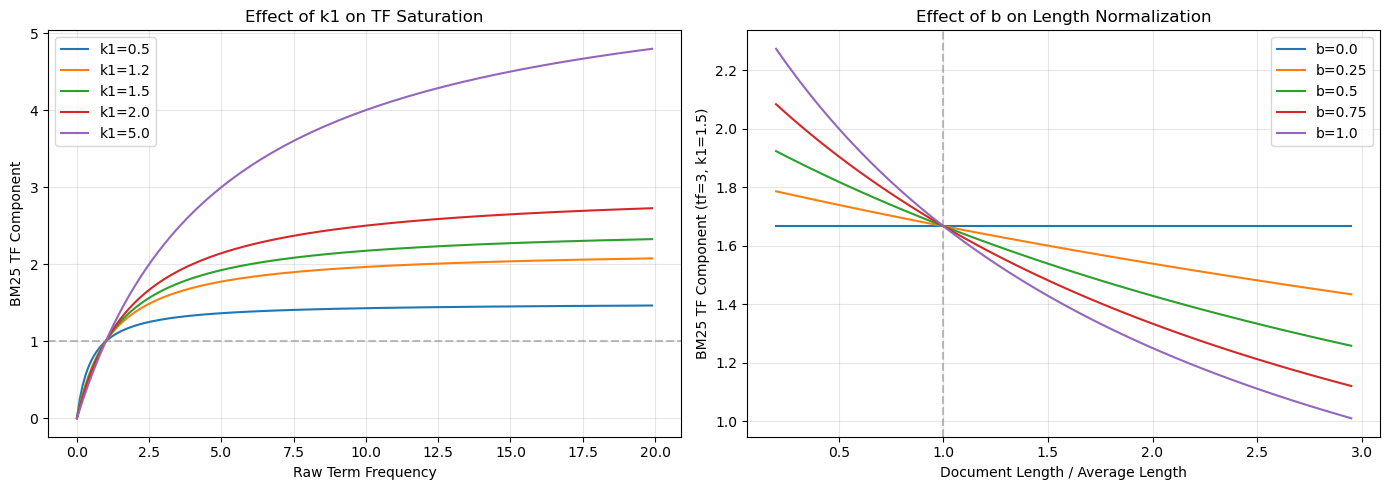

In [8]:
# Visualize TF saturation for different k1 values
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Left plot: Effect of k1 on TF saturation
tf_range = np.arange(0, 20, 0.1)
for k1 in [0.5, 1.2, 1.5, 2.0, 5.0]:
    saturated_tf = (tf_range * (k1 + 1)) / (tf_range + k1)
    ax1.plot(tf_range, saturated_tf, label=f'k1={k1}')

ax1.set_xlabel('Raw Term Frequency')
ax1.set_ylabel('BM25 TF Component')
ax1.set_title('Effect of k1 on TF Saturation')
ax1.legend()
ax1.grid(True, alpha=0.3)
ax1.axhline(y=1, color='gray', linestyle='--', alpha=0.5, label='TF=1 baseline')

# Right plot: Effect of b on document length normalization
dl_ratios = np.arange(0.2, 3.0, 0.05)  # doc_len / avgdl
k1 = 1.5
tf_val = 3  # Fixed TF
for b in [0.0, 0.25, 0.5, 0.75, 1.0]:
    scores = (tf_val * (k1 + 1)) / (tf_val + k1 * (1 - b + b * dl_ratios))
    ax2.plot(dl_ratios, scores, label=f'b={b}')

ax2.set_xlabel('Document Length / Average Length')
ax2.set_ylabel('BM25 TF Component (tf=3, k1=1.5)')
ax2.set_title('Effect of b on Length Normalization')
ax2.legend()
ax2.grid(True, alpha=0.3)
ax2.axvline(x=1.0, color='gray', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

**Key Takeaways from the Plots:**

**Left Plot - TF Saturation (`k1`):**
- Low `k1` (0.5): TF saturates quickly - the difference between 1 and 10 occurrences is small
- High `k1` (5.0): TF grows more linearly - more occurrences continue to boost the score
- `k1=0` would reduce BM25 to a binary model (term present or not)
- Typical values: 1.2 to 2.0

**Right Plot - Length Normalization (`b`):**
- `b=0`: No length normalization - long and short documents scored equally
- `b=1`: Full normalization - documents are strongly penalized/rewarded based on length
- Documents shorter than average get a boost; longer ones are penalized
- Typical value: 0.75

## Section 3: BM25 on a Real Dataset

Let's use a real question-answering dataset to see BM25 in action.

In [10]:
!pip install rank_bm25

In [11]:
from datasets import load_dataset
from rank_bm25 import BM25Okapi
from tqdm import tqdm

# Load Natural Questions (simplified) - a real QA dataset from Google
dataset = load_dataset("rag-datasets/rag-mini-wikipedia", "text-corpus", split="passages")

print(f"Loaded {len(dataset)} passages")
print(f"\nSample passage:")
print(f"  {dataset[0]}")

README.md:   0%|          | 0.00/719 [00:00<?, ?B/s]

data/passages.parquet/part.0.parquet:   0%|          | 0.00/797k [00:00<?, ?B/s]

Generating passages split:   0%|          | 0/3200 [00:00<?, ? examples/s]

Loaded 3200 passages

Sample passage:
  {'passage': 'Uruguay (official full name in  ; pron.  , Eastern Republic of  Uruguay) is a country located in the southeastern part of South America.  It is home to 3.3 million people, of which 1.7 million live in the capital Montevideo and its metropolitan area.', 'id': 0}


In [12]:
# Build BM25 index over the passages
passages = [item["passage"] for item in dataset]
tokenized_passages = [tokenize(p) for p in tqdm(passages, desc="Tokenizing")]

bm25_index = BM25Okapi(tokenized_passages)
print(f"BM25 index built over {len(passages)} passages")

Tokenizing: 100%|██████████| 3200/3200 [00:00<00:00, 220665.74it/s]

BM25 index built over 3200 passages


In [13]:
def bm25_retrieve(query, top_k=5):
    """Retrieve top-k passages for a query using BM25."""
    query_tokens = tokenize(query)
    scores = bm25_index.get_scores(query_tokens)
    top_indices = np.argsort(scores)[::-1][:top_k]
    
    results = []
    for idx in top_indices:
        results.append({
            "passage": passages[idx],
            "score": scores[idx],
            "index": idx
        })
    return results

# Test retrieval
test_queries = [
    "What is the capital of France?",
    "Who invented the telephone?",
    "How does photosynthesis work?",
]

for query in test_queries:
    print(f"\nQuery: '{query}'")
    print("-" * 60)
    results = bm25_retrieve(query, top_k=3)
    for rank, r in enumerate(results, 1):
        print(f"  [{rank}] (score={r['score']:.3f}) {r['passage'][:150]}...")


Query: 'What is the capital of France?'
------------------------------------------------------------
  [1] (score=13.665) Montevideo, capital of the country. A view of pedestrian street in the Ciudad Vieja, former Spanish citadel...
  [2] (score=13.650) Romania has been a member of the European Union since January 1 2007, and has the ninth largest territory in the EU and with 22 million people      it...
  [3] (score=13.304) Jakarta, the capital of Indonesia and its largest commercial center...

Query: 'Who invented the telephone?'
------------------------------------------------------------
  [1] (score=14.757) * Lomas, Robert, " The Man who Invented the Twentieth Century". Lecture to South Western Branch of Instititute of Physics....
  [2] (score=10.006) As a chemist, Faraday discovered benzene, investigated the clathrate hydrate of chlorine, invented an early form of the bunsen burner and the system o...
  [3] (score=9.095) In mechanics, Newton enunciated the principles of conserva

## Section 4: BM25 vs Dense Retrieval - A Quick Comparison

BM25 is a **sparse** retrieval method - it relies on exact term matching. **Dense** retrieval uses neural embeddings to capture semantic similarity. Let's compare them.

In [15]:
!pip install sentence_transformers

In [16]:
from sentence_transformers import SentenceTransformer

# Load a small but effective dense retrieval model
dense_model = SentenceTransformer('all-MiniLM-L6-v2')

# Encode a subset of passages (full corpus would take longer)
subset_size = min(5000, len(passages))
subset_passages = passages[:subset_size]

print(f"Encoding {subset_size} passages with dense model...")
passage_embeddings = dense_model.encode(
    subset_passages,
    show_progress_bar=True,
    batch_size=64
)
print(f"Embedding shape: {passage_embeddings.shape}")

modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/612 [00:00<?, ?B/s]

...

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

Encoding 3200 passages with dense model...


Batches:   0%|          | 0/50 [00:00<?, ?it/s]

Embedding shape: (3200, 384)


In [17]:
def dense_retrieve(query, top_k=5):
    """Retrieve top-k passages using dense embeddings."""
    query_embedding = dense_model.encode([query])
    # Cosine similarity (embeddings are already normalized by SentenceTransformer)
    similarities = np.dot(passage_embeddings, query_embedding.T).flatten()
    top_indices = np.argsort(similarities)[::-1][:top_k]
    
    results = []
    for idx in top_indices:
        results.append({
            "passage": subset_passages[idx],
            "score": similarities[idx],
            "index": idx
        })
    return results

# Compare BM25 and Dense retrieval side by side
comparison_queries = [
    "What is the capital of France?",             # Exact term match - BM25 should do well
    "How do plants convert sunlight to energy?",   # Semantic - Dense might do better
    "biggest country in the world by area",        # Paraphrase - Dense might do better
]

for query in comparison_queries:
    print(f"\nQuery: '{query}'")
    print("=" * 70)
    
    bm25_results = bm25_retrieve(query, top_k=2)
    dense_results = dense_retrieve(query, top_k=2)
    
    print("  BM25 Results:")
    for rank, r in enumerate(bm25_results, 1):
        print(f"    [{rank}] (score={r['score']:.3f}) {r['passage'][:120]}...")
    
    print("  Dense Results:")
    for rank, r in enumerate(dense_results, 1):
        print(f"    [{rank}] (score={r['score']:.3f}) {r['passage'][:120]}...")


Query: 'What is the capital of France?'
  BM25 Results:
    [1] (score=13.665) Montevideo, capital of the country. A view of pedestrian street in the Ciudad Vieja, former Spanish citadel...
    [2] (score=13.650) Romania has been a member of the European Union since January 1 2007, and has the ninth largest territory in the EU and ...
  Dense Results:
    [1] (score=0.409) Montevideo, Uruguay's capital....
    [2] (score=0.402) French explorer Samuel de Champlain arrived in 1603 and established the first permanent European settlements at Port Roy...

Query: 'How do plants convert sunlight to energy?'
  BM25 Results:
    [1] (score=9.390) See  for an explanation of how to generate footnotes using the   and   tags, and the template below. ...
    [2] (score=9.390) *  Entomology - online insect museum, entomology, tips and tricks, how to spread and pin insects, etc....
  Dense Results:
    [1] (score=0.383) *By pulling down trees to eat leaves, breaking branches, and pulling out roots th

### Sparse vs Dense Retrieval: Trade-offs

| Aspect | BM25 (Sparse) | Dense Retrieval |
|--------|--------------|----------------|
| **Matching** | Exact term overlap | Semantic similarity |
| **Speed** | Very fast (inverted index) | Slower (ANN search needed) |
| **Index size** | Small | Large (embedding vectors) |
| **Synonyms** | Misses them | Handles them |
| **Rare terms** | Excellent (high IDF) | Can struggle |
| **Training** | None needed | Requires training data |
| **Out-of-domain** | Robust | May degrade |

**In practice, BM25 remains a very strong baseline.** Many production RAG systems use BM25 either standalone or as part of a hybrid retriever.